## 1. Import the libraries:

In [1]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import os
import numpy as np
from IPython.display import display, Markdown, Image


import chart_studio.plotly as py
import plotly.express as px
import plotly.graph_objects as go
import cufflinks as cf
import matplotlib.pyplot as plt
%matplotlib inline


import warnings
warnings.filterwarnings("ignore")

from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
cf.go_offline()

## 2. Connect the database:

In [2]:
db_path = "../data/ecommerce.db"
conn = sqlite3.connect(db_path)
print(f"Database connection was success!: {conn}")

Database connection was success!: <sqlite3.Connection object at 0x00000201EAAA34C0>


## 3. Get the list of the available tables:

In [3]:
# Get the list of the available tables:
all_tables= """ 
                SELECT 
                    name  
                FROM 
                    sqlite_master 
                WHERE 
                    type='table'; 
            """

tables = pd.read_sql_query(all_tables, conn)
print(f"The list of the tables:\n{tables}")

The list of the tables:
                           name
0                     customers
1                   geolocation
2                        orders
3                   order_items
4                order_payments
5                 order_reviews
6                      products
7                       sellers
8  product_category_translation


# Customer Segmentation (RFM Analysis)

### Objective:
Segment the customers based on their **purchase behavior** to identify high-value customers, churn risk, and growth opportunities.

#  1. Baseline RFM Construction:

### Q. How can customers be segmented based on Recency, Frequency, and Monetary value?

### Data Scope Definition:

For RFM analysis, the orders with `order_status=delivered` are considered. 
This ensures that:
1. Revenue has been fully realized
2. The transaction represents a completed customer purchase
3. Customer behavior is measured based on confirmed buying activity rather than intent or failed transactions

A temporary table `customer_order_info`is created for further analysis:

In [4]:
cursor = conn.cursor()

cursor.execute("""DROP TABLE IF EXISTS customer_order_info;""")

cursor.execute("""
                CREATE TEMP TABLE customer_order_info  AS 
                SELECT
                    oi.order_id, oi.order_item_id, oi.price, oi.freight_value,
                    oi.product_id,
                    o.customer_id, o.order_status, o.order_purchase_timestamp
                FROM
                    order_items oi INNER JOIN orders o
                        ON oi.order_id = o.order_id;
                """)

## 1.1  Recency Analysis:

- Recency asks **"When did the customer made their last purchase that was successfull or the `order status was delivered`?**
- In business terms:
    - `Low Recency (recent purchases)`: active or engaged customers
    - `High Recency (long-time ago)`: inactive, churn-risk customers
    
But this dataset is old and using the current date won't make sense, so for this analysis, the latest date from the 
`order_purchase_timestamp + 10 DAYS` will be used as the threshold.

In [5]:
recency_table_full_q = """
        WITH customer_order_window AS (
                                    SELECT
                                        customer_id, order_purchase_timestamp,
                                        ROW_NUMBER() OVER(PARTITION BY customer_ID ORDER BY order_purchase_timestamp DESC) AS test
                                    FROM
                                        customer_order_info
                                        ),
                                        
             data_threshold AS (
                                SELECT
                                    DATE(MAX(order_purchase_timestamp), '+10 days') AS date_threshold
                               FROM
                                   customer_order_info                               
                               ),
                               
             recency_table AS (        
                            SELECT
                                cow.customer_id,
                                DATE(cow.order_purchase_timestamp) AS latest_purchase_timestamp,
                                dt.date_threshold AS date_threshold,
                                CAST(JULIANDAY(dt.date_threshold) - JULIANDAY(cow.order_purchase_timestamp) AS INTEGER) AS days_since_last_purchase
                            FROM
                                customer_order_window cow CROSS JOIN data_threshold dt
                            WHERE
                                test = 1
                              )
        
        
             SELECT
                 customer_id,
                 latest_purchase_timestamp,
                 date_threshold,
                 days_since_last_purchase,
                 CAST((days_since_last_purchase / 50) * 10 AS INTEGER) AS bins
             FROM recency_table;
        """

recency_table_full = pd.read_sql_query(recency_table_full_q, conn)

In [6]:
customers_per_bins = recency_table_full.groupby(['bins'])['customer_id'].nunique()

In [7]:
customers_per_bins

bins
0       8124
10     10020
20     11180
30     11680
40     11809
50     11417
60      7555
70      7036
80      6140
90      5839
100     4139
110     3149
120      267
140      311
Name: customer_id, dtype: int64

In [8]:
recency_table_full.head()

,customer_id,latest_purchase_timestamp,date_threshold,days_since_last_purchase,bins
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14,2018-09-13,302,60
1,000161a058600d5901f007fab4c27140,2017-07-16,2018-09-13,423,80
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28,2018-09-13,561,110
3,0002414f95344307404f0ace7a26f1d5,2017-08-16,2018-09-13,392,70
4,000379cdec625522490c315e70c7a9fb,2018-04-02,2018-09-13,163,30


In [9]:
bins = np.sort(recency_table_full['bins'].unique())

In [10]:
bins

array([  0,  10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120,
       140])

In [11]:
customers_per_bins_labeled = customers_per_bins.copy()

bin_mapping = {
    0: '0-50',
    10: '50-100',
    20: '100-150',
    30: '150-200',
    40: '200-250',
    50: '250-300',
    60: '300-350',
    70: '350-400',
    80: '400-450',
    90: '450-500',
    100: '500-550',
    110: '550-600',
    120: '600-650',
    140: '650+'
}

customers_per_bins_labeled.index = customers_per_bins_labeled.index.map(bin_mapping)
customers_per_bins_labeled

customers_per_bins_labeled_df = customers_per_bins_labeled.to_frame().reset_index().rename(columns={'bins': 'Days Interval',
                                                                                                   'customer_id': 'Total Customers'})
fig = px.bar(x=customers_per_bins_labeled_df['Days Interval'], y=customers_per_bins_labeled_df['Total Customers'],
             labels={'x': 'Recency Bins (Days)', 'y': 'Number Of Customers'},
             text=customers_per_bins_labeled_df['Total Customers'],
             title = 'Customers Distribution By Recency')


## Recency Analysis Conclusion:

Recency measures how long it has been since a customer’s **most recent completed purchase.** 

In this analysis:
- Only orders with `delivered` status were considered to ensure revenue realization.
- **Recency** was calculated as the number of days between a customer's latest purchase timestamp and a threshold set as
`DATE(MAX(order_purchase_timestamp), '+10 days')` .i.e. **2018-09-13**. This approach was 
chosen because the dataset is historical, and using the current date would distort recency values.

- Each customer is recorded once using a `WINDOW FUNCTION` to capture their most recent purchase.

The resulting table `recency_table_full` holds the entire information at a customer level, leaving space for further
segmentation and drill-down analysis when required, `recency_table_full` holds a data of **98666** rows 
and **5** features, as a glimpse, here is what it looks like: 

,customer_id,latest_purchase_timestamp,date_threshold,days_since_last_purchase,bins
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14,2018-09-13,302,60
1,000161a058600d5901f007fab4c27140,2017-07-16,2018-09-13,423,80
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28,2018-09-13,561,110
3,0002414f95344307404f0ace7a26f1d5,2017-08-16,2018-09-13,392,70
4,000379cdec625522490c315e70c7a9fb,2018-04-02,2018-09-13,163,30



To improve interpretability, customers were grouped into **50-day recency bins**, allowing the analysis to be performed
at an aggregated level while preserving the underlying customer-level data:


,Days Interval,Total Customers
0,0-50,8124
1,50-100,10020
2,100-150,11180
3,150-200,11680
4,200-250,11809
5,250-300,11417
6,300-350,7555
7,350-400,7036
8,400-450,6140
9,450-500,5839



The chart below visualizes the distribution of customers across recency bins, highlighting how customer activity
declines as time since last purchase increases:


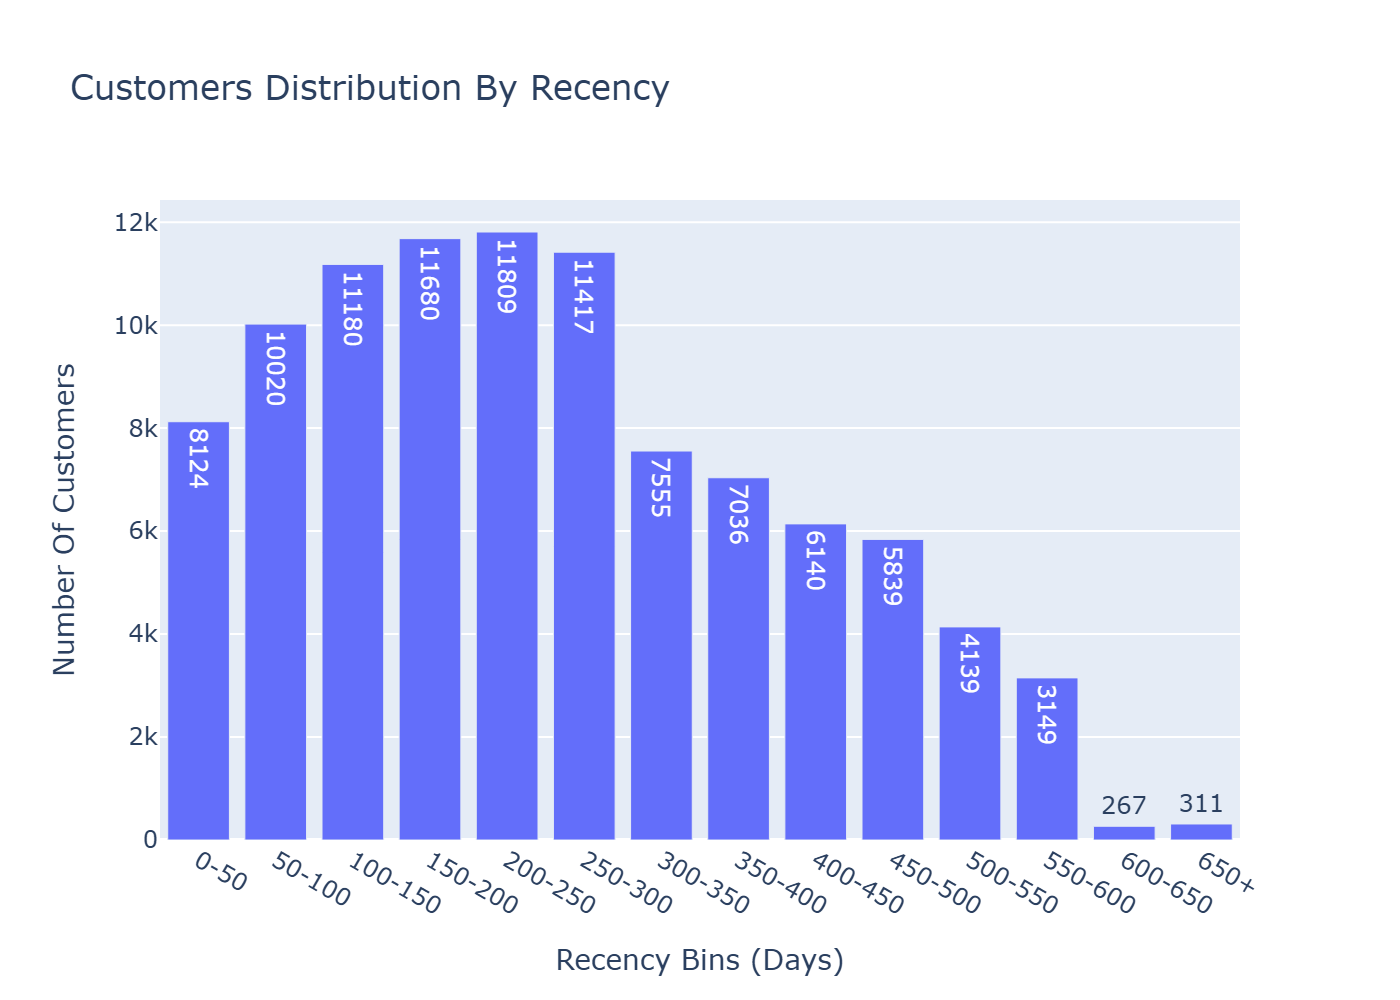

In [18]:
display(Markdown(f"""
## Recency Analysis Conclusion:

Recency measures how long it has been since a customer’s **most recent completed purchase.** 

In this analysis:
- Only orders with `delivered` status were considered to ensure revenue realization.
- **Recency** was calculated as the number of days between a customer's latest purchase timestamp and a threshold set as
`DATE(MAX(order_purchase_timestamp), '+10 days')` .i.e. **{recency_table_full['date_threshold'].iloc[0]}**. This approach was 
chosen because the dataset is historical, and using the current date would distort recency values.

- Each customer is recorded once using a `WINDOW FUNCTION` to capture their most recent purchase.

The resulting table `recency_table_full` holds the entire information at a customer level, leaving space for further
segmentation and drill-down analysis when required, `recency_table_full` holds a data of **{recency_table_full.shape[0]}** rows 
and **{recency_table_full.shape[1]}** features, as a glimpse, here is what it looks like: """))
display(recency_table_full.head(5))


display(Markdown(f"""
To improve interpretability, customers were grouped into **50-day recency bins**, allowing the analysis to be performed
at an aggregated level while preserving the underlying customer-level data:
"""))
display(customers_per_bins_labeled_df)

display(Markdown("""
The chart below visualizes the distribution of customers across recency bins, highlighting how customer activity
declines as time since last purchase increases:
"""))
fig.show()
fig.write_image("../plots/Customers_Distribution_By_Recency.png", scale=2)
display(Image(filename="../plots/Customers_Distribution_By_Recency.png"))

## 1.2 Frequency Analysis:

- Frequency asks **"How often does a customer make a purchase?"**
- In business terms,
    - `High Frequency`: loyal customers
    - `Low Frequency`: one-time customer or chustomer who are at churn-risk


In [20]:
tables

,name
0,customers
1,geolocation
2,orders
3,order_items
4,order_payments
5,order_reviews
6,products
7,sellers
8,product_category_translation


In [58]:
q = "SELECT * FROM customers LIMIT 2;"

r = pd.read_sql_query(q, conn)

In [59]:
r

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [109]:
customer_order_frequency_interpretation_q = """
        
        WITH customer_full_IDs AS (
                                    SELECT
                                        coi.order_id, 
                                        coi.customer_id,
                                        c.customer_unique_id
                                     FROM
                                         customer_order_info coi INNER JOIN customers c
                                             ON coi.customer_id = c.customer_id
                                      ),
                                      
             
             orders_per_customer AS (
                                      SELECT
                                          customer_unique_id,
                                          COUNT(DISTINCT order_id) AS total_orders
                                      FROM
                                          customer_full_IDs
                                      GROUP BY
                                          customer_unique_id
                                     )
                                     
             SELECT
                 customer_unique_id,
                 total_orders,
                 CASE 
                     WHEN total_orders = 1 THEN 'One-Time Buyer'
                     WHEN total_orders = 2 THEN 'Returning Customer'
                     WHEN total_orders = 3 THEN 'Loyal Customer'
                     WHEN total_orders = 4 THEN 'Very Loyal'
                     ELSE 'VIP Customers'
                 END AS Interpretation                   
             FROM
                 orders_per_customer;
       """


customer_order_frequency_interpretation = pd.read_sql_query(customer_order_frequency_interpretation_q,conn)

In [110]:
customer_order_frequency_interpretation.head(3)

,customer_unique_id,total_orders,Interpretation
0,0000366f3b9a7992bf8c76cfdf3221e2,1,One-Time Buyer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-Time Buyer
2,0000f46a3911fa3c0805444483337064,1,One-Time Buyer


In [142]:
customer_order_frequency_interpretation_counts = customer_order_frequency_interpretation['Interpretation'].value_counts()
customer_order_frequency_interpretation_counts = customer_order_frequency_interpretation_counts.to_frame().reset_index()
customer_order_frequency_interpretation_counts.rename(columns={'count':'Total Counts'}, inplace=True)
customer_order_frequency_interpretation_counts['Customer Share (%)'] = np.round((customer_order_frequency_interpretation_counts['Total Counts']
                                                                        / customer_order_frequency_interpretation_counts['Total Counts'].sum()) * 100, 3)

In [143]:
customer_order_frequency_interpretation_counts

,Interpretation,Total Counts,Customer Share (%)
0,One-Time Buyer,92507,96.947
1,Returning Customer,2673,2.801
2,Loyal Customer,192,0.201
3,Very Loyal,29,0.030
4,VIP Customers,19,0.020


In [148]:
import plotly.express as px

fig = px.bar(customer_order_frequency_interpretation_counts,
             x='Interpretation',
             y='Customer Share (%)',
             text='Customer Share (%)',
             hover_data={'Total Counts': True},
             title='Customer Segmentation by Purchase Frequency',
             labels={'Interpretation':'Customer Segment', 'Customer Share (%)':'Customer Share (%)',
                    'Total Counts': 'Total Customers'})

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.update_yaxes(type='log')
fig.show()
